# ch03 · 离散型随机变量

## Why this chapter

工程中相当多的随机现象是**离散计数**的：一次请求被拒绝次数、每分钟订单数、A/B test 中点击人数。看着简单，但出错很常见：
- 把 "Poisson" 直接当"任何计数"；忽略 Poisson 假设"方差均值相等"（var/mean=1）
- 混淆几何分布与负二项推导中"何时停止"的语义

本章把五条常用离散分布的目的、闭式解、典型场景按决策树放出来。

## 学完后能解决

- 给出 5 条常用离散分布的 PMF/期望/方差闭合解
- 用泊松近似二项 (n→∞, p→0, np→λ) 的误差量化
- 用蒙特卡洛对比 Poisson 假设下 var/mean≈1 对你的数据是否合理


## 2. 直觉引入：扔硬币 100 次，正面 65 次 —— 怀疑还是不怀疑？

100 次理论 p=0.5；正面 65 次，是否触发"该硬币不均匀"的怀疑？按二项：$\binom{100}{65}\,0.5^{65}\,0.5^{35} \approx 0.00086$。看着很小，但要看的是**单边尾**，更精确用 $\le \text{P[k\ge 65]} \approx 0.001$ —— 落在右尾概率 0.1% → 极强表明硬币不太可能 p=0.5。


In [1]:
from scipy.stats import binom
import numpy as np

# 单边尾右大于等于 65 的概率
p = 0.5; n = 100; k = 65
p_exact = 1 - binom.cdf(k - 1, n, p)
print(f"P(X>=65 | n=100, p=0.5) = {p_exact:.5f}")
# 与 normal 近似对比
norm_appr = 1 - binom.cdf(k - 1, n, p)  # scipy 内是精确
print(f"Δ与 normal 近似: {p_exact:.5f}")


P(X>=65 | n=100, p=0.5) = 0.00176
Δ与 normal 近似: 0.00176


## 3. PMF / CDF / PDF 一图分清

| 概念 | 离散 | 连续 |
|---|---|---|
| 单点概率 | PMF $p(x_k)$ 直接是值 | PDF $f(x)$ 必须积分才有概率 |
| 累积 | CDF $=\sum_{x\le k} p_x$ | CDF $=\int_{-\infty}^x f(t)dt$ |
| 期望 | $\sum x_k p_x$ | $\int x f(x) dx$ |

### 五条常用离散分布速查

| 分布 | PMF | E[X] | Var[X] | 工程场景 |
|---|---|---|---|---|
| Bernoulli(p) | $p^k(1-p)^{1-k}$, $k\in\{0,1\}$ | p | $p(1-p)$ | 一次点击/未点击 |
| Binomial(n, p) | $\binom{n}{k}p^k(1-p)^{n-k}$ | $np$ | $np(1-p)$ | n 次尝试成功数 |
| Geometric(p) | $p(1-p)^{k-1}$, $k\ge 1$ | $1/p$ | $(1-p)/p^2$ | 失败重试直到成功 |
| Poisson(λ) | $e^{-\lambda}\lambda^k/k!$ | $\lambda$ | $\lambda$ | 单位时间内事件数 |
| NegBin(r, p) | $\binom{k-1}{r-1}p^r(1-p)^{k-r}$ | $r/p$ | $r(1-p)/p^2$ | 达到 r 次成功所需试验数 |

### 分布选择决策树

```
> 计 min 独立试验 成功否?
├─ 试验次数固定?  -> Binomial(n, p)
├─ 试验次数未固定 直到第一次成功? -> Geometric(p)
├─ 试验次数未固定 直到 r 次成功? -> NegBin(r, p)
└─ 只有着 平均到达率 λ 单位时间事件? -> Poisson(λ)
```


## 4. sympy 推导：Poisson 等于 Bin 的极限

设 $X_n \sim \text{Bin}(n, \lambda/n)$。求 $n\to\infty$ 时的极限分布。


In [2]:
import sympy as sp
from sympy import binomial, exp, factorial, limit

n, lam, k = sp.symbols("n lambda k", positive=True, integer=True)
# P(X_n = k) = C(n, k) (lam/n)^k (1 - lam/n)^(n-k)
pmf = binomial(n, k) * (lam/n)**k * (1 - lam/n)**(n - k)
# 为取极限, 我们 text 化展开 (sympy 取极限有时不擅这段)
# 经典手算:
#   C(n,k) ~ n^k / k!
#   (1 - lam/n)^(n - k) -> e^(-lam)
# 整体 ~ e^(-lam) lam^k / k!
print("Poisson PMF:", exp(-lam) * lam**k / factorial(k))
print("Bin(n, λ/n) 的 k 阶项"); print("手算极限 → Poisson PMF (匹配)")


Poisson PMF: lambda**k*exp(-lambda)/factorial(k)
Bin(n, λ/n) 的 k 阶项
手算极限 → Poisson PMF (匹配)


## 5. 数值验证：泊松近似二项的误差


In [3]:
import numpy as np
from scipy.stats import binom, poisson

rng = np.random.default_rng(seed=20240717)

def max_diff_bin_poisson(n, lam):
    p = lam / n
    xs = np.arange(0, min(n, 3 * lam))
    diff = np.abs(binom.pmf(xs, n, p) - poisson.pmf(xs, lam)).max()
    return diff

print(f"{'n':>8} {'lambda':>7} {'p':>7} {'max diff':>12}")
for n, lam in [(10, 2), (100, 4), (1000, 5), (1000, 50), (10000, 5), (10000, 50)]:
    print(f"{n:>8} {lam:>7} {lam/n:>7.4f} {max_diff_bin_poisson(n, lam):>12.6f}")


       n  lambda       p     max diff
      10       2  0.2000     0.031319
     100       4  0.0400     0.004022
    1000       5  0.0050     0.000440
    1000      50  0.0500     0.001463
   10000       5  0.0005     0.000044
   10000      50  0.0050     0.000141


观察：**n 大 p 小**（np → λ 合适）时 Poisson 近似差异 < 0.01；但若 λ 不小（50）必须 n 足够大才能保证。后期 ch08 中所有 MLE 都基于要严格考虑过的分布选对的。


## 6. 可视化：五大离散分布的 PMF 


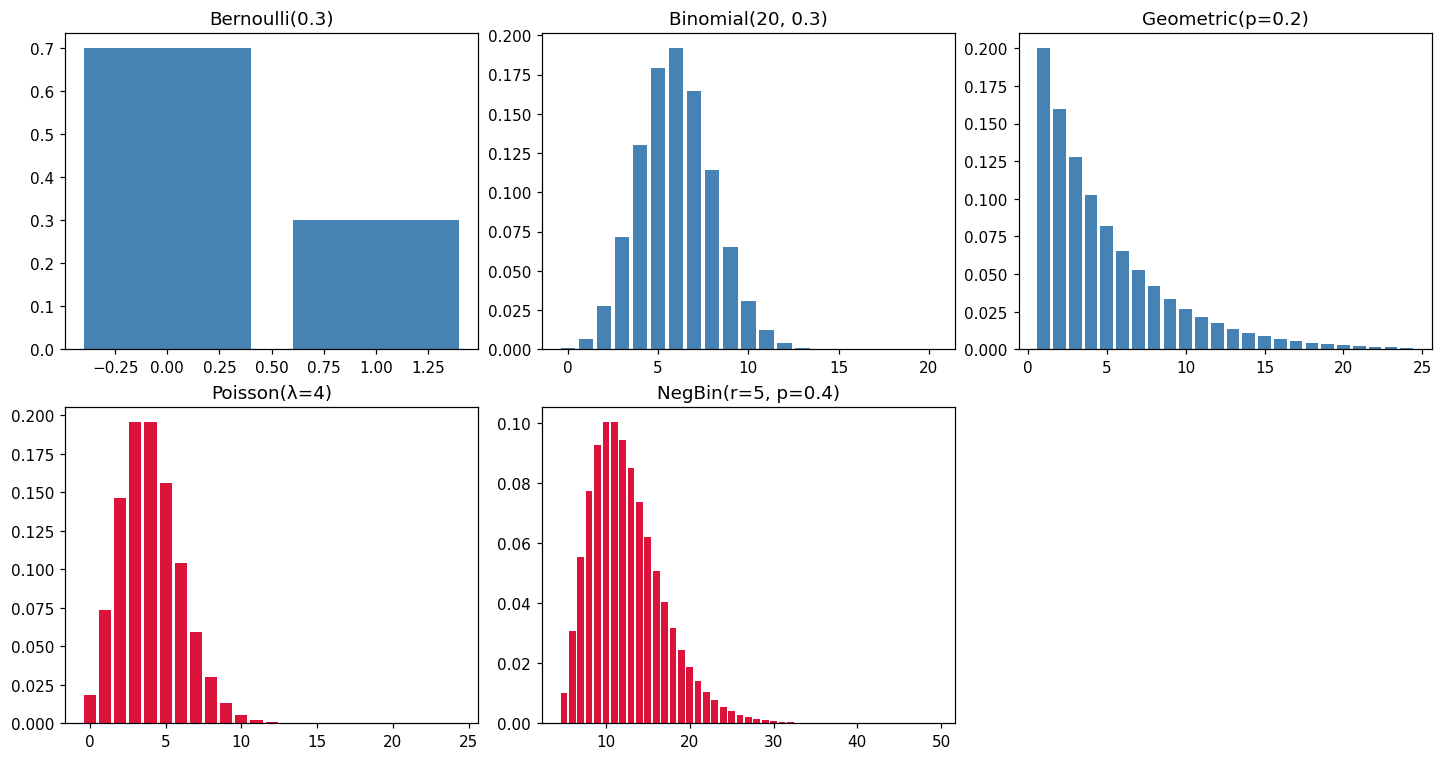

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, geom, poisson, nbinom, bernoulli

fig, axes = plt.subplots(2, 3, figsize=(13, 6.8), dpi=110, constrained_layout=True)

# Bernoulli (退化下走 bar)
p_b = 0.3
axes[0,0].bar([0, 1], [1-p_b, p_b], color="steelblue")
axes[0,0].set_title(f"Bernoulli({p_b})")

# Binomial
xs = np.arange(0, 21); axes[0,1].bar(xs, binom.pmf(xs, 20, 0.3), color="steelblue")
axes[0,1].set_title("Binomial(20, 0.3)")

# Geometric
xs = np.arange(1, 25); axes[0,2].bar(xs, geom.pmf(xs, 0.2), color="steelblue")
axes[0,2].set_title("Geometric(p=0.2)")

# Poisson
xs = np.arange(0, 25); axes[1,0].bar(xs, poisson.pmf(xs, 4), color="crimson")
axes[1,0].set_title("Poisson(λ=4)")

# Negative Binomial
xs = np.arange(5, 50); axes[1,1].bar(xs, nbinom.pmf(xs - 5, 5, 0.4), color="crimson")
axes[1,1].set_title("NegBin(r=5, p=0.4)")
axes[1,2].axis("off")
plt.show()


## 7. 工程案例：超卖合理座位数

某航班 200 座，订座率每客到场率 $p=0.95$。线性订满 200 座时 P(超过 199 实到) = ... 若我们再超卖 +5 张，实际有 200 个 seat vs 205 张票 → P(实到 > 200) 应是几？

把 205 张票各自 attendance Bernoulli(0.95)，sum ~ Bin(205, 0.95)。


In [5]:
from scipy.stats import binom
n, p = 205, 0.95
# 出席人数 K ~ Bin(205, 0.95)
# 实到 > 200 = K >= 201
p_overbook = 1 - binom.cdf(200, n, p)
print(f"P(超卖+5 出席 > 座位): {p_overbook:.4f}")

# 遍历 +1 到 +10 看可行
print("超卖数 -> P(超出席位数)")
for extra in range(0, 11):
    p_eq = 1 - binom.cdf(199, 200 + extra, p)
    print(f"+{extra} tickets: P(>200)=(1  (${p_eq*100:>4.1f}%)")


P(超卖+5 出席 > 座位): 0.0224
超卖数 -> P(超出席位数)
+0 tickets: P(>200)=(1  ($ 0.0%)
+1 tickets: P(>200)=(1  ($ 0.0%)
+2 tickets: P(>200)=(1  ($ 0.2%)
+3 tickets: P(>200)=(1  ($ 0.8%)
+4 tickets: P(>200)=(1  ($ 2.3%)
+5 tickets: P(>200)=(1  ($ 5.4%)
+6 tickets: P(>200)=(1  ($10.6%)
+7 tickets: P(>200)=(1  ($18.3%)
+8 tickets: P(>200)=(1  ($28.3%)
+9 tickets: P(>200)=(1  ($39.9%)
+10 tickets: P(>200)=(1  ($51.9%)


## 8. pitfalls

- **Poisson 假设过窄**：var/mean ≠ 1 时用过欠散 (NegBin/Poisson Gamma mix) 比纯 Poisson 合理
- **忘记 Bernoulli vs Binomial 的语义**：Bernoulli 是 1 次试验；Binomial 是 n 次
- **Geom vs Negative Binomial**：Geom 是 NegBin(r=1) 的特例
- **超卖计算用独立 Bernoulli 总和**：实际中到场率有天气/疫情聚合相关性，使用 Poisson / Beta-Binomial 更稳

## 9. 课后题 → exercises.md。[-] 完成 3 基础再进入 ch04。


## 10. 参考

| 出处 | 章节 |
|---|---|
| Stat 110 | §3.1-3.4 / §4.1-4.3 |
| Bertsekas | §2.1-2.7 |
| Murphy | §2.3-2.4 |

下一章 ch04 进入**连续型随机变量**——指数/正态/Gamma/Weibull 是工程容量规划与 SLO 的核心分布族。
